# 1. Load Dynamo & Data

In [1]:
# Necessary to prevent kernel crash at sc.pp.neighbors()
import numba
numba.set_num_threads(1)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="numpy.dtype size changed")

import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')
dyn.pl.style(font_path='Arial')

import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
import anndata as ad
import harmonypy as hp

Using already downloaded Arial font from: /var/folders/_0/8l2kpxvj13b9xcgqzjm3mkjw0000gn/T/dynamo_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered custom font as: Arial


 ███                               ████████        
█████   █████    █████    █████    ███   █████      
   ██████   ██████   ██████   ████████      ████ 
  ___                           ████            ███
 |   \ _  _ _ _  __ _ _ __  ___                 ███
 | |) | || | ' \/ _` | '  \/ _ \█████           ███ 
 |___/ \_, |_||_\__,_|_|_|_\___/█████       ████  
       |__/                        ███   █████     
Tutorial: https://dynamo-release.readthedocs.io/       
                                     █████      



In [3]:
def process_adata(path):
    adata = dyn.read("data/" + path)
    
    # Drop duplicate gene symbols and modify for Dynamo format
    symbols = adata.var["gene_symbols"].astype(str).values
    unique_symbols, index_inverse = np.unique(symbols, return_inverse=True)
    
    # Summing matrix: original genes x unique genes
    # This is a sparse matrix of 1s that tells the computer which rows to sum
    row = np.arange(len(symbols))
    col = index_inverse
    data = np.ones(len(symbols))
    S = sparse.csr_matrix((data, (row, col)), shape=(len(symbols), len(unique_symbols)))

    # Take the first occurrence of each symbol to keep metadata (like chromosome)
    _, first_indices = np.unique(symbols, return_index=True)
    var_unique = adata.var.iloc[first_indices].copy()
    var_unique.index = symbols[first_indices]
    var_unique.index.name = None
    
    # cells x genes) @ (genes x unique genes)
    new_X = adata.X @ S
    
    new_adata = ad.AnnData(X=new_X, obs=adata.obs.copy(), var=var_unique)
    
    for layer in ['spliced', 'unspliced']:
        if layer in adata.layers:
            new_adata.layers[layer] = adata.layers[layer] @ S
            
    print(new_adata)
    return new_adata

files = ['SRX21172619.h5ad', 'SRX23456399.h5ad', 'SRX21788827.h5ad', 'SRX21788830.h5ad']
adata_list = [process_adata(f) for f in files]
adata = ad.concat(adata_list, join='inner', label='condition', 
                  keys=['Control', 'NMDA 36hrs', 'NMDA 72hrs', 'NMDA 96hrs'])
print("Concatenated adata:", adata) #17.7s

AnnData object with n_obs × n_vars = 16064 × 25404
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'spliced', 'unspliced'
AnnData object with n_obs × n_vars = 29896 × 25404
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'spliced', 'unspliced'
AnnData object with n_obs × n_vars = 27622 × 25404
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'spliced', 'unspliced'
AnnData object with n_obs × n_vars = 28182 × 25404
    obs: 'gene_coun

# 2. Preprocessing

In [4]:
preprocessor = dyn.pp.Preprocessor()
preprocessor.preprocess_adata(adata, recipe="monocle")
# 30s

|-----> Running monocle preprocessing pipeline...
|-----------> filtered out 2123 outlier cells
|-----------> filtered out 16240 outlier genes
|-----> PCA dimension reduction
|-----> <insert> X_pca to obsm in AnnData Object.
|-----> [Preprocessor-monocle] completed [24.8087s]

╭─ SUMMARY: Preprocessor.preprocess_adata ───────────────────────────╮
│  Duration: 24.8148s                                                │
│  Shape:    101,764 x 25,404 -> 99,641 x 25,404                     │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ Size_Factor (float)                                  │
│           │ ✚ initial_cell_size (float)                            │
│           │ ✚ initial_spliced_cell_size (float)                    │
│           │ ✚ initial_unspliced_cell_size (float)                  │
│           

In [7]:
# Use Harmony to reduce batch effects
adata.obsm['X_pca_harmony'] = hp.run_harmony(adata.obsm['X_pca'], adata.obs, 'condition').Z_corr

2026-03-08 00:44:43,674 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-03-08 00:44:43,675 - harmonypy - INFO -   Parameters:
2026-03-08 00:44:43,675 - harmonypy - INFO -     max_iter_harmony: 10
2026-03-08 00:44:43,675 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-08 00:44:43,675 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-08 00:44:43,675 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-08 00:44:43,676 - harmonypy - INFO -     nclust: 100
2026-03-08 00:44:43,676 - harmonypy - INFO -     block_size: 0.05
2026-03-08 00:44:43,676 - harmonypy - INFO -     lamb: [1. 1. 1. 1.]
2026-03-08 00:44:43,676 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-03-08 00:44:43,677 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-03-08 00:44:43,677 - harmonypy - INFO -     verbose: True
2026-03-08 00:44:43,677 - harmonypy - INFO -     random_state: 0
2026-03-08 00:44:43,677 - harmonypy - INFO -   Data: 30 PCs × 99641 cells
2026-03-08 00:44:43,677 - harm

In [8]:
sc.pp.neighbors(adata, 
                n_neighbors=10, # Large number of neighbors give more global features
                n_pcs=30,
                use_rep="X_pca_harmony")
# 10s

In [9]:
sc.tl.leiden(adata,
             resolution=0.5, # Larger values give more clusters
             flavor="igraph",
             n_iterations=2,
             directed=False,
             random_state=28,
)

In [10]:
sc.tl.umap(adata,
           spread = 1,
           min_dist=0.5) # The effective minimum distance between embedded points
                         # Smaller values will result in a more clustered/clumped embedding
# 30s

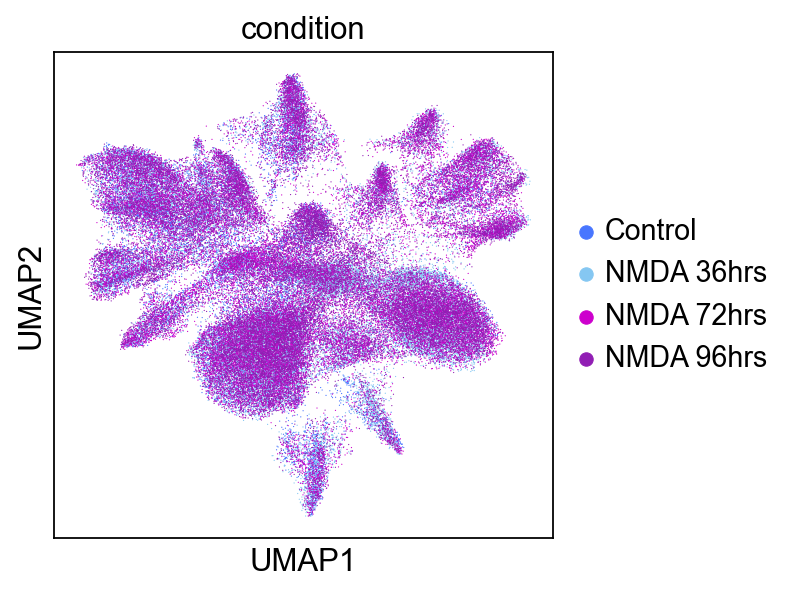

In [11]:
# Check if batch effect is corrected
sc.pl.umap(adata, color="condition")

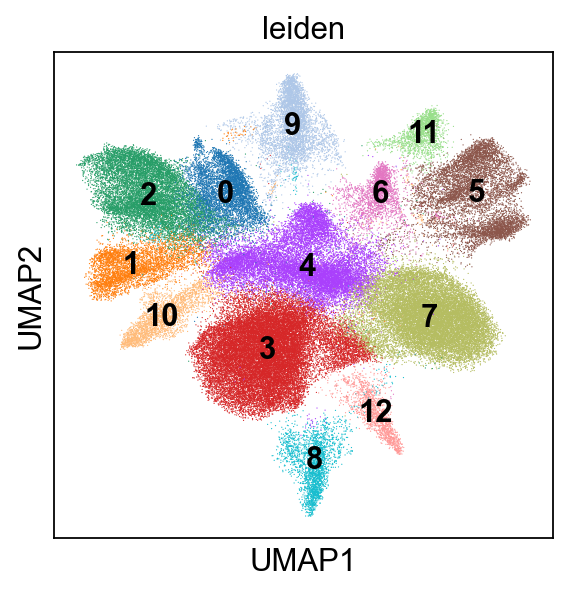

In [12]:
# Coarse cell clusters
sc.pl.umap(adata, 
           color="leiden", 
           legend_loc="on data")
# 13 Clusters

# 3. Cell type annotations

In [13]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
DEG = pd.DataFrame(adata.uns['rank_genes_groups']['names'])
DEG.head(30)
# 1m 30s

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,slc6a9,rbpms2a,syt1a,grin1b,mt-atp6,prph2a,opn1sw1,rho,grna,SLC4A5,slc1a2b,opn1sw2,stra6
1,grin1a,rtn1a,slc6a1b,slc12a5b,mt-co2,slc24a2,ly6pge,si:ch211-113d22.2,ctsc,tnr,rhbg,prph2a,rgrb
2,syt1a,islr2,sv2a,zfhx4,mt-co3,clul1,prph2a,rom1b,mrc1b,pcdh8,nfasca,rbp4l,rbp5
3,nrxn1a,grin1a,slc32a1,nova2,si:dkey-151g10.6,rbp4l,spock3,pde6gb,psap,ENSDARG00000116725,mdka,clul1,tyrp1b
4,pax6b,elavl3,gad2,aplp1,mt-co1,six7,clul1,gnat1,lgals3bp.1,mdka,selenop,opn6b,rpe65a
5,gpm6aa,gpm6ab,gpm6aa,lrit1a,rplp1,prph2b,fat1b,gnb1a,ctsba,vtnb,aqp1a.1,spock3,pmelb
6,pax6a,rbpms2b,pclob,rs1a,mt-nd4,pde6c,opn6b,pde6b,cd74b,atp1b1a,col18a1a,slc24a2,msnb
7,slc32a1,si:dkey-7j14.5,tkta,nell2b,hmgn2,laptm4b,prph2b,gnb1b,lgals9l1,slc12a2,zgc:165604,arr3b,ctsd
8,ppfia4,atp2b3b,atp1a3a,b3galt2,fabp7a,SAMD4B,rbp4l,cnga1a,apoc1,clu,pik3ip1,prph2b,pmela
9,sv2a,igfbp5b,grin1b,vamp1a,mt-nd1,SLC38A5,slc24a2,gngt1,cd68,syt1a,id1,tmem237a,ambp


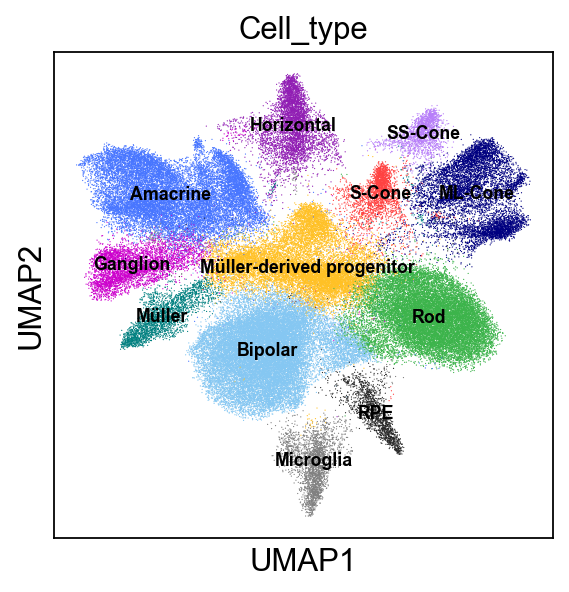

In [27]:
cluster_annotation = {
    "0": "Amacrine", 
    "1": "Ganglion", 
    "2": "Amacrine",
    "3": "Bipolar", 
    "4": "Müller-derived progenitor", 
    "5": "ML-Cone", # Try dividing it into red and green
    "6": "S-Cone", 
    "7": "Rod", 
    "8": "Microglia",
    "9": "Horizontal", 
    "10": "Müller", 
    "11": "SS-Cone",
    "12": "RPE"
}

adata.obs["Cell_type"] = adata.obs["leiden"].map(cluster_annotation)

sc.pl.umap(adata, color="Cell_type", legend_loc="on data", legend_fontsize=8)

In [29]:
# Save results
adata.write('results/adata_celltype_annotated.h5ad')

In [30]:
# Save results by condition
conditions = adata.obs['condition'].unique()
adata_subsets = {cond: adata[adata.obs['condition'] == cond].copy() for cond in conditions}

In [31]:
adata_subsets['Control'].write('results/adata_cont_celltype_annotated.h5ad')
adata_subsets['NMDA 36hrs'].write('results/adata_nmda36_celltype_annotated.h5ad')
adata_subsets['NMDA 72hrs'].write('results/adata_nmda72_celltype_annotated.h5ad')
adata_subsets['NMDA 96hrs'].write('results/adata_nmda96_celltype_annotated.h5ad')